# Sequential workflow and prompt chaining

# in parallel flow, return partial updates
# in sequential return full state update

In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import OpenAI
from dotenv import load_dotenv
import os

In [20]:
load_dotenv()  
model = OpenAI(model="gpt-4.1-nano")

In [21]:
class blog_state(TypedDict):
    title:str
    outline:str
    content:str

In [22]:
def create_outline(state:blog_state)->blog_state:
    title = state['title']
    prompt = f"generate an short outline for the blog post titled '{title}"
    outline = model.invoke(prompt)
    state['outline'] = outline
    return state


def generate_content(state:blog_state)->blog_state:
    title = state['title']
    outline = state['outline']
    prompt = f"write a detailed blog post based on the following title and outline.\nTitle: {title}\nOutline: {outline}"
    content = model.invoke(prompt)
    state['content'] = content
    return state

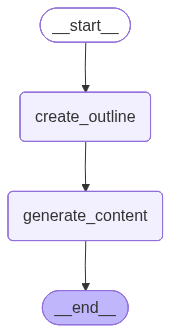

In [23]:
graph = StateGraph(blog_state)

# add nodes
graph.add_node("create_outline", create_outline)
graph.add_node("generate_content", generate_content)

# add edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "generate_content")
graph.add_edge("generate_content", END)

workflow = graph.compile()
workflow


In [24]:
initial_state = {"title":"The Future of AI: Trends and Predictions for the Next Decade"}
final_state = workflow.invoke(initial_state)


In [25]:
print(final_state['outline'])

' in a short outline format. 1. Introduction
2. Current State of AI
3. Key Trends in AI Development
   a. Advancements in Machine Learning
   b. Expansion of AI in Industry
   c. Ethical Considerations and AI Governance
4. Predictions for the Next Decade
   a. AI in Everyday Life
   b. AI and Human Collaboration
   c. Regulations and Ethical Frameworks
5. Challenges and Risks
6. Conclusion and Future Outlook"

1. Introduction
2. Current State of AI
3. Key Trends in AI Development
   a. Advancements in Machine Learning
   b. Expansion of AI in Industry
   c. Ethical Considerations and AI Governance
4. Predictions for the Next Decade
   a. AI in Everyday Life
   b. AI and Human Collaboration
   c. Regulations and Ethical Frameworks
5. Challenges and Risks
6. Conclusion and Future Outlook

*Note: This is a short outline and can be expanded with more detailed points for each section.*

Certainly! Here's a slightly expanded version of the outline with brief points for each section:

1. **In

In [26]:
print(final_state['content'])


   - Purpose of the discussion

2. **Current State of AI**
   - AI capabilities today (e.g., NLP, computer vision)
   - Major players and innovations
   - Limitations and challenges faced

3. **Key Trends in AI Development**
   a. *Advancements in Machine Learning*
      - Deep learning breakthroughs
      - Transfer learning and few-shot learning
   b. *Expansion of AI in Industry*
      - Healthcare, finance, manufacturing
      - AI-driven automation
   c. *Ethical Considerations and AI Governance*
      - Bias, privacy, transparency
      - International cooperation and regulation

4. **Predictions for the Next Decade**
   a. *AI in Everyday Life*
      - Personal assistants, smart homes
      - Autonomous vehicles
   b. *AI and Human Collaboration*
      - Augmented decision-making
      - Creative collaboration
   c. *Regulations and Ethical Frameworks*
      - Developing global standards
      - Balancing innovation with safety

5. **Challenges and Risks**
   - Job displacement

In [27]:
print(final_state)

{'title': 'The Future of AI: Trends and Predictions for the Next Decade', 'outline': '\' in a short outline format. 1. Introduction\n2. Current State of AI\n3. Key Trends in AI Development\n   a. Advancements in Machine Learning\n   b. Expansion of AI in Industry\n   c. Ethical Considerations and AI Governance\n4. Predictions for the Next Decade\n   a. AI in Everyday Life\n   b. AI and Human Collaboration\n   c. Regulations and Ethical Frameworks\n5. Challenges and Risks\n6. Conclusion and Future Outlook"\n\n1. Introduction\n2. Current State of AI\n3. Key Trends in AI Development\n   a. Advancements in Machine Learning\n   b. Expansion of AI in Industry\n   c. Ethical Considerations and AI Governance\n4. Predictions for the Next Decade\n   a. AI in Everyday Life\n   b. AI and Human Collaboration\n   c. Regulations and Ethical Frameworks\n5. Challenges and Risks\n6. Conclusion and Future Outlook\n\n*Note: This is a short outline and can be expanded with more detailed points for each sec